In [ ]:
system("apt-get update -qq")
system("apt-get install -y -qq libfftw3-dev libtiff5-dev libpng-dev libjpeg-dev python3-venv python3-pip python3-dev")

install.packages("BiocManager")
BiocManager::install("EBImage", update = FALSE, ask = FALSE)

install.packages("keras")
library(keras)
install_keras()

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'EBImage'”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Virtual environment 'r-tensorflow' removed.
Using Python: /usr/bin/python3.10
Creating virtual environment 'r-tensorflow' ... 


+ /usr/bin/python3.10 -m venv /root/.virtualenvs/r-tensorflow



Done!
Installing packages: pip, wheel, setuptools


+ /root/.virtualenvs/r-tensorflow/bin/python -m pip install --upgrade pip wheel setuptools



Virtual environment 'r-tensorflow' successfully created.
Using virtual environment 'r-tensorflow' ...


+ /root/.virtualenvs/r-tensorflow/bin/python -m pip install --upgrade --no-user 'numpy<2' 'tensorflow==2.15.*' tensorflow-hub tensorflow-datasets scipy requests Pillow h5py pandas pydot tf-keras




Installation complete.



In [ ]:
setwd("/content")

draw_plane <- function(filename, seed) {
  set.seed(seed)
  jpeg(filename, width = 200, height = 200, quality = 90)
  par(mar = c(0,0,0,0), bg = "skyblue")
  plot(0, 0, type = "n", xlim = c(0,10), ylim = c(0,10), xlab = "", ylab = "", axes = FALSE)
  polygon(c(1,8,9,8,1), c(5,5.7,5,4.3,5), col = "gray30", border = "black")
  polygon(c(3,5,3), c(5,8,5), col = "gray50", border = "black")
  polygon(c(3,5,3), c(5,2,5), col = "gray50", border = "black")
  polygon(c(1,2,1), c(5,7,5), col = "gray50", border = "black")
  dev.off()
}

draw_car <- function(filename, seed) {
  set.seed(seed)
  jpeg(filename, width = 200, height = 200, quality = 90)
  par(mar = c(0,0,0,0), bg = "white")
  plot(0, 0, type = "n", xlim = c(0,10), ylim = c(0,10), xlab = "", ylab = "", axes = FALSE)
  rect(1, 3, 9, 6, col = "firebrick", border = "black")
  polygon(c(3,4,6,7), c(6,8,8,6), col = "lightblue", border = "black")
  symbols(c(3,7), c(3,3), circles = c(1,1), inches = FALSE, add = TRUE, bg = "black")
  dev.off()
}

for (i in 1:6) draw_plane(paste0("p", i, ".jpg"), seed = i)
for (i in 1:6) draw_car(paste0("c", i, ".jpg"), seed = i + 100)

# Verify the 12 files exist before moving on
list.files("/content", pattern = "\\.jpg$")

[1] "c1.jpg" "c2.jpg" "c3.jpg" "c4.jpg" "c5.jpg" "c6.jpg" "p1.jpg" "p2.jpg"
 [9] "p3.jpg" "p4.jpg" "p5.jpg" "p6.jpg"

In [ ]:
library(EBImage)
library(keras)

setwd("/content")

pics <- c('p1.jpg','p2.jpg','p3.jpg','p4.jpg','p5.jpg','p6.jpg',
          'c1.jpg','c2.jpg','c3.jpg','c4.jpg','c5.jpg','c6.jpg')

stopifnot(all(file.exists(pics)))   # will stop with a clear error if any file is missing

mypic <- list()
for (i in 1:12) {mypic[[i]] <- readImage(pics[i])}

Image 
  colorMode    : Color 
  storage.mode : double 
  dim          : 200 200 3 
  frames.total : 3 
  frames.render: 1 

imageData(object)[1:5,1:6,1]
          [,1]      [,2]      [,3]      [,4]      [,5]      [,6]
[1,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118
[2,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118
[3,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118
[4,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118
[5,] 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118 0.5294118


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.5294  0.8078  0.7247  0.9176  0.9725 

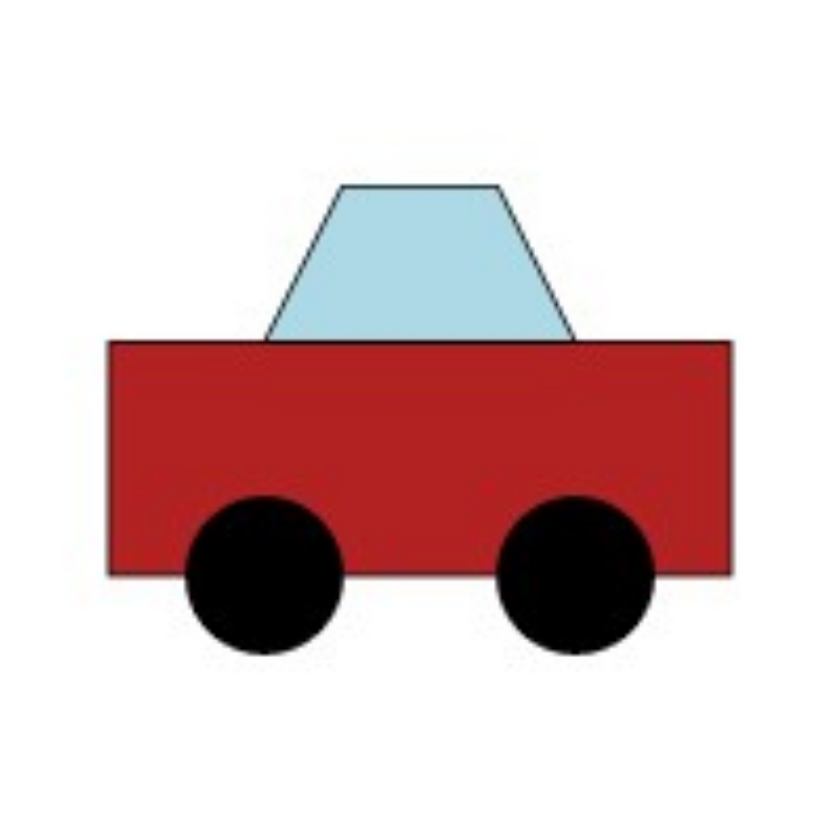

List of 12
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:200, 1:200, 1:3] 0.529 0.529 0.529 0.529 0.529 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 200 200 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:200, 1:200, 1:3] 0.529 0.529 0.529 0.529 0.529 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 200 200 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:200, 1:200, 1:3] 0.529 0.529 0.529 0.529 0.529 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 200 200 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:200, 1:200, 1:3] 0.529 0.529 0.529 0.529 0.529 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 200 200 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:200, 1:200, 1:3] 0.529 0.529 0.529 0.529 0.529 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 200 200 3
 $ :Forma

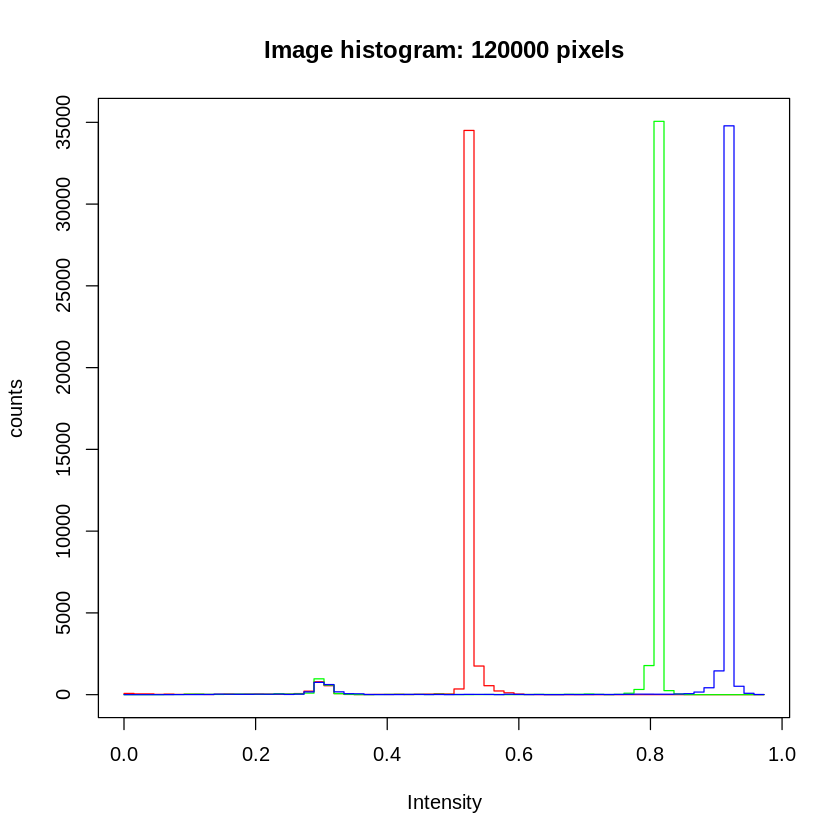

In [ ]:
print(mypic[[1]])
display(mypic[[8]])
summary(mypic[[1]])
hist(mypic[[2]])
str(mypic)

In [ ]:
for (i in 1:12) {mypic[[i]] <- resize(mypic[[i]], 28, 28)}
for (i in 1:12) {mypic[[i]] <- array_reshape(mypic[[i]], c(28, 28, 3))}

In [ ]:
trainx <- NULL
for (i in c(1,2,3,4,5, 7,8,9,10,11)) {trainx <- rbind(trainx, mypic[[i]])}
testx  <- rbind(mypic[[6]], mypic[[12]])
str(trainx)

trainy <- c(0,0,0,0,0, 1,1,1,1,1)   # 0 = plane, 1 = car
testy  <- c(0, 1)

trainLabels <- to_categorical(trainy)
testLabels  <- to_categorical(testy)

 num [1:10, 1:2352] 0.529 0.529 0.529 0.529 0.529 ...


In [ ]:
model <- keras_model_sequential()
model %>%
  layer_dense(units = 256, activation = 'relu', input_shape = c(2352)) %>%
  layer_dense(units = 128, activation = 'relu') %>%
  layer_dense(units = 2, activation = 'softmax')
summary(model)

Model: "sequential"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 dense_2 (Dense)                    (None, 256)                     602368      
 dense_1 (Dense)                    (None, 128)                     32896       
 dense (Dense)                      (None, 2)                       258         
Total params: 635522 (2.42 MB)
Trainable params: 635522 (2.42 MB)
Non-trainable params: 0 (0.00 Byte)
________________________________________________________________________________


In [ ]:
model %>% compile(loss = 'binary_crossentropy',
                   optimizer = optimizer_rmsprop(),
                   metrics = c('accuracy'))

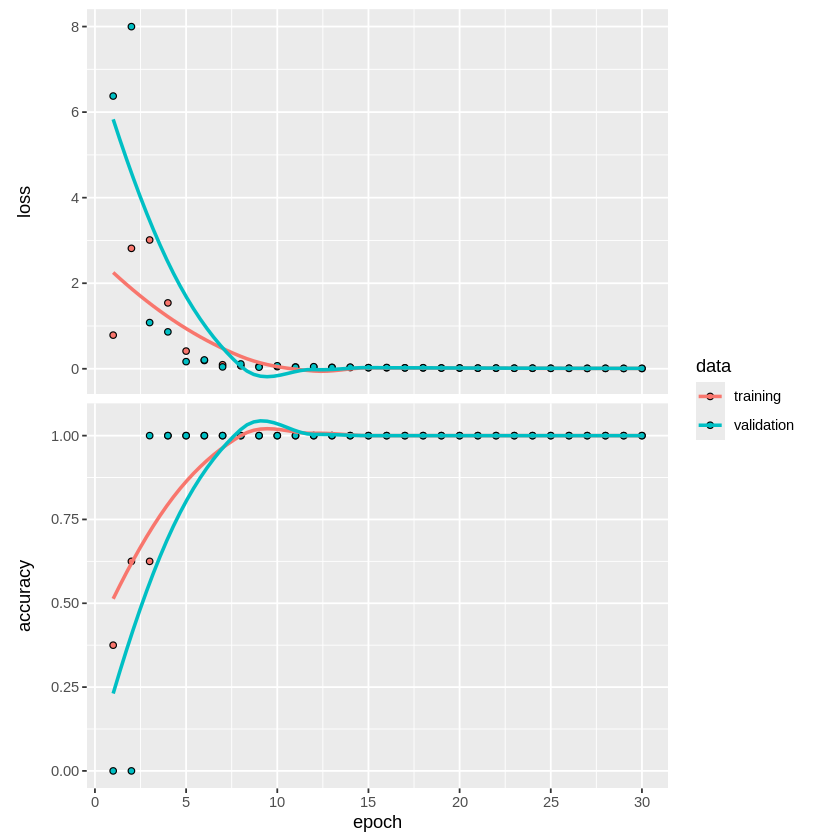

In [ ]:
history <- model %>%
  fit(trainx,
      trainLabels,
      epochs = 30,
      batch_size = 32,
      validation_split = 0.2)

plot(history)



In [ ]:
model %>% evaluate(trainx, trainLabels)

prob <- model %>% predict(trainx)
pred <- apply(prob, 1, which.max) - 1

table(Predicted = pred, Actual = trainy)
cbind(prob, Predicted = pred, Actual = trainy)

loss    accuracy 
0.007203209 1.000000000

         Actual
Predicted 0 1
        0 5 0
        1 0 5

,,Predicted,Actual
9.999757e-01,2.425701e-05,0,0
9.999757e-01,2.425701e-05,0,0
9.999757e-01,2.425701e-05,0,0
9.999757e-01,2.425701e-05,0,0
9.999757e-01,2.425701e-05,0,0
8.518453e-05,9.999147e-01,1,1
8.518453e-05,9.999147e-01,1,1
8.518453e-05,9.999147e-01,1,1
8.518453e-05,9.999148e-01,1,1
8.518453e-05,9.999148e-01,1,1


In [ ]:
model %>% evaluate(testx, testLabels)

prob_test <- model %>% predict(testx)
pred_test <- apply(prob_test, 1, which.max) - 1

table(Predicted = pred_test, Actual = testy)
cbind(prob_test, Predicted = pred_test, Actual = testy)

loss    accuracy 
0.007203206 1.000000000

         Actual
Predicted 0 1
        0 1 0
        1 0 1

,,Predicted,Actual
9.999758e-01,2.425697e-05,0,0
8.518453e-05,9.999148e-01,1,1
